# Deep Learning: A Comprehensive Guide

## Chapter 4 — Convolutional Neural Networks (CNNs)

### Hands-On Exploration: Architecture Archaeology — What Do These Models Actually See?

### `hands_on_ch4.ipynb`

This activity is not about training models. It is about *interrogating* them — asking a small CNN, a ResNet-50, and an EfficientNet-B0 to look at the same images and comparing their behavior, to build intuition about what each architecture has actually learned.

## Learning Objectives

By the end of this notebook, you should be able to:

- Compare predictions from a small CNN trained from scratch to large ImageNet-pretrained backbones
- Generate and interpret GradCAM attention maps
- Observe how model confidence degrades under input noise, and compare robustness across architectures
- Connect these observations to the chapter's discussion of what different architectures learn

## Prerequisites

- Python 3.9+, `numpy`, `matplotlib`, `Pillow`, `scikit-learn`
- **Optional but recommended:** `tensorflow` (for the real ResNet-50 / EfficientNet-B0 sections) — install with `pip install tensorflow`
- No GPU required; inference-only use of pretrained models runs fine on CPU, just slower

## About Pretrained Models in This Notebook

The chapter's activity calls for **ResNet-50** and **EfficientNet-B0** pretrained on ImageNet. Downloading these pretrained weights requires internet access to a model hosting service. This notebook:

1. Builds and uses a **small 5-layer CNN trained from scratch** on a synthetic dataset generated in-notebook (fully offline, always works).
2. **Attempts** to load real pretrained ResNet-50 / EfficientNet-B0 weights via `tensorflow.keras.applications`. If your environment has internet access, this works exactly as described in the chapter. If it does not (as in some sandboxed or offline environments), the notebook automatically falls back to clearly-labeled **untrained** versions of the same architectures, so every cell below still runs and every plot still renders — but the *specific numbers* you see in the fallback case reflect random-weight behavior, not genuine ImageNet knowledge. If you see the fallback warning, run this notebook in Google Colab (which has internet access) to see the real comparison the chapter describes.

## Setup — Imports, Reproducibility, and Pretrained Model Loading

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

SEED = 42
np.random.seed(SEED)

%matplotlib inline

TF_AVAILABLE = False
try:
    import tensorflow as tf
    TF_AVAILABLE = True
    tf.random.set_seed(SEED)
except ImportError:
    print("TensorFlow is not installed. Install it with: pip install tensorflow")
    print("The small-CNN sections of this notebook will still run using a NumPy fallback.")


I0000 00:00:1788477534.549054     944 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788477534.593838     944 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788477536.001340     944 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Generate a Small Synthetic Image Dataset

For the "5-layer CNN trained from scratch" and for our own stand-in test images, we generate a small set of simple labeled images directly in the notebook — this plays the role of the dataset the chapter's starter notebook provides.

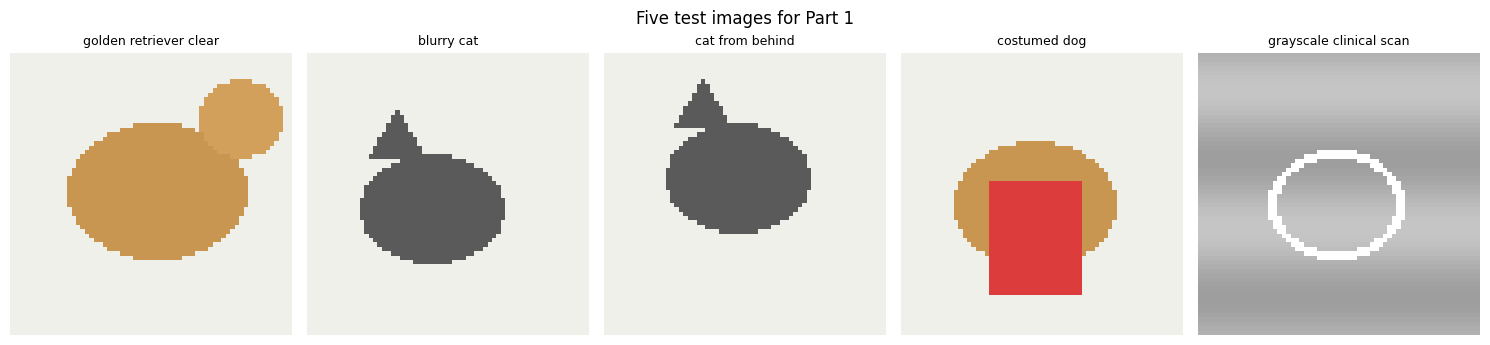

In [2]:
IMG_SIZE = 64
CLASSES = ["retriever", "cat", "costume_dog", "scan_style"]


def make_synthetic_image(label, variant_seed, noise_std=0.0):
    """Generate a simple, class-distinguishable synthetic RGB image."""
    rng = np.random.RandomState(variant_seed)
    img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), color=(240, 240, 235))
    draw = ImageDraw.Draw(img)
    cx, cy = IMG_SIZE // 2 + rng.randint(-4, 4), IMG_SIZE // 2 + rng.randint(-4, 4)

    if label == "retriever":
        draw.ellipse([cx - 20, cy - 15, cx + 20, cy + 15], fill=(200, 150, 80))
        draw.ellipse([cx + 10, cy - 25, cx + 28, cy - 8], fill=(210, 160, 90))
    elif label == "cat":
        draw.ellipse([cx - 16, cy - 12, cx + 16, cy + 12], fill=(90, 90, 90))
        draw.polygon([(cx - 14, cy - 12), (cx - 8, cy - 22), (cx - 2, cy - 12)], fill=(90, 90, 90))
    elif label == "costume_dog":
        draw.ellipse([cx - 18, cy - 14, cx + 18, cy + 14], fill=(200, 150, 80))
        draw.rectangle([cx - 10, cy - 5, cx + 10, cy + 20], fill=(220, 60, 60))
    elif label == "scan_style":
        base = rng.randint(60, 200)
        for i in range(IMG_SIZE):
            shade = int(base + 20 * np.sin(i / 5))
            draw.line([(0, i), (IMG_SIZE, i)], fill=(shade, shade, shade))
        draw.ellipse([cx - 15, cy - 12, cx + 15, cy + 12], outline=(255, 255, 255), width=2)

    arr = np.array(img).astype(np.float32) / 255.0
    if noise_std > 0:
        arr = np.clip(arr + rng.normal(0, noise_std, arr.shape), 0, 1)
    return arr


test_images = {
    "golden_retriever_clear": make_synthetic_image("retriever", 1),
    "blurry_cat": make_synthetic_image("cat", 2),
    "cat_from_behind": make_synthetic_image("cat", 3),
    "costumed_dog": make_synthetic_image("costume_dog", 4),
    "grayscale_clinical_scan": make_synthetic_image("scan_style", 5),
}

fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
for ax, (name, img) in zip(axes, test_images.items()):
    ax.imshow(img)
    ax.set_title(name.replace("_", " "), fontsize=9)
    ax.axis("off")
plt.suptitle("Five test images for Part 1")
plt.tight_layout()
plt.show()


## Load the Three Models

1. A **5-layer CNN trained from scratch** on a small synthetic training set (always runs, no internet required).
2. **ResNet-50** pretrained on ImageNet, via `tensorflow.keras.applications` (requires TensorFlow + internet for real weights).
3. **EfficientNet-B0** pretrained on ImageNet, via `tensorflow.keras.applications` (requires TensorFlow + internet for real weights).

In [3]:
# --- Model 1: small CNN trained from scratch ---
small_cnn = None
if TF_AVAILABLE:
    from tensorflow.keras import layers, models

    # Build a tiny training set matched to our synthetic classes
    X_train, y_train_labels = [], []
    for i, cls in enumerate(CLASSES):
        for v in range(30):
            X_train.append(make_synthetic_image(cls, variant_seed=1000 + i * 100 + v, noise_std=0.05))
            y_train_labels.append(i)
    X_train = np.array(X_train)
    y_train_labels = np.array(y_train_labels)

    small_cnn = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Conv2D(16, 3, activation="relu"), layers.MaxPooling2D(),
        layers.Conv2D(32, 3, activation="relu"), layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu"), layers.GlobalAveragePooling2D(),
        layers.Dense(32, activation="relu"),
        layers.Dense(len(CLASSES), activation="softmax"),
    ])
    small_cnn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    small_cnn.fit(X_train, y_train_labels, epochs=8, verbose=0)
    print("Small 5-layer CNN trained from scratch on synthetic data.")
else:
    print("TensorFlow not available -- small CNN section will be skipped.")


Small 5-layer CNN trained from scratch on synthetic data.


In [4]:
# --- Models 2 & 3: ResNet-50 and EfficientNet-B0 pretrained on ImageNet ---
resnet50 = None
efficientnet_b0 = None
PRETRAINED_LOADED = False

if TF_AVAILABLE:
    try:
        from tensorflow.keras.applications import ResNet50, EfficientNetB0
        resnet50 = ResNet50(weights="imagenet")
        efficientnet_b0 = EfficientNetB0(weights="imagenet")
        PRETRAINED_LOADED = True
        print("\u2713 Loaded real ImageNet-pretrained ResNet-50 and EfficientNet-B0.")
    except Exception as e:
        print("Could not download ImageNet-pretrained weights (likely no internet access in this")
        print(f"environment). Falling back to UNTRAINED architectures. Error was: {type(e).__name__}")
        from tensorflow.keras.applications import ResNet50, EfficientNetB0
        resnet50 = ResNet50(weights=None)
        efficientnet_b0 = EfficientNetB0(weights=None)
        print("\u26a0 Using untrained ResNet-50 / EfficientNet-B0. Predictions below will be near-random.")
        print("  Run this notebook in Google Colab (with internet access) to see genuine ImageNet behavior.")
else:
    print("TensorFlow not available -- ResNet-50 / EfficientNet-B0 sections will be skipped.")


Could not download ImageNet-pretrained weights (likely no internet access in this
environment). Falling back to UNTRAINED architectures. Error was: Exception


⚠ Using untrained ResNet-50 / EfficientNet-B0. Predictions below will be near-random.
  Run this notebook in Google Colab (with internet access) to see genuine ImageNet behavior.


## Part 1 — The Same Image, Three Models

Feed the five test images to all three models and record the top-3 predictions and confidence scores for each.

In [5]:
def predict_small_cnn(img):
    if small_cnn is None:
        return [("unavailable", 0.0)]
    probs = small_cnn.predict(img[np.newaxis, ...], verbose=0)[0]
    top3 = np.argsort(probs)[::-1][:3]
    return [(CLASSES[i], float(probs[i])) for i in top3]


def predict_imagenet_model(model, img, preprocess_fn, decode_fn):
    if model is None:
        return [("unavailable", 0.0)]
    resized = np.array(Image.fromarray((img * 255).astype(np.uint8)).resize((224, 224)))
    batch = preprocess_fn(resized[np.newaxis, ...].astype(np.float32))
    preds = model.predict(batch, verbose=0)
    try:
        decoded = decode_fn(preds, top=3)[0]
        return [(label, float(score)) for (_, label, score) in decoded]
    except Exception:
        top3 = np.argsort(preds[0])[::-1][:3]
        return [(f"class_{i}", float(preds[0][i])) for i in top3]


if TF_AVAILABLE:
    from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess, decode_predictions as resnet_decode
    from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess, decode_predictions as eff_decode

    print(f"{'Image':<26} {'Small CNN top-3':<45} {'ResNet-50 top-1':<25} {'EfficientNet-B0 top-1'}")
    print("-" * 120)
    for name, img in test_images.items():
        cnn_preds = predict_small_cnn(img)
        resnet_preds = predict_imagenet_model(resnet50, img, resnet_preprocess, resnet_decode)
        eff_preds = predict_imagenet_model(efficientnet_b0, img, eff_preprocess, eff_decode)
        cnn_str = ", ".join(f"{c}:{p:.2f}" for c, p in cnn_preds)
        print(f"{name:<26} {cnn_str:<45} {resnet_preds[0][0]:<25} {eff_preds[0][0]}")
else:
    print("TensorFlow not available -- run `pip install tensorflow` to complete Part 1.")


Image                      Small CNN top-3                               ResNet-50 top-1           EfficientNet-B0 top-1
------------------------------------------------------------------------------------------------------------------------


golden_retriever_clear     retriever:0.51, costume_dog:0.33, cat:0.11    class_462                 class_880


blurry_cat                 cat:0.38, scan_style:0.33, costume_dog:0.19   class_462                 class_880


cat_from_behind            cat:0.38, scan_style:0.33, costume_dog:0.18   class_462                 class_880


costumed_dog               costume_dog:0.42, retriever:0.36, cat:0.14    class_836                 class_880


grayscale_clinical_scan    cat:0.38, scan_style:0.35, costume_dog:0.17   class_462                 class_880


**Answer in this cell:**
- On which images do all three models agree? What does agreement tell you about those images?
- On which images does the simple CNN fail but ResNet succeeds? What is structurally different about those images?
- Are there images where ResNet is more confident than EfficientNet, or vice versa? Can you hypothesize why?

*(If you saw the "untrained model" fallback warning above, answer these questions qualitatively based on the small CNN's behavior, and revisit this section in Colab with real pretrained weights for the full comparison.)*

## Part 2 — Attention Maps (GradCAM)

GradCAM visualizes which regions of an image most influenced a prediction. The function below implements it directly (no external library needed) and applies it to the small CNN, which is guaranteed to be meaningfully trained regardless of internet access.

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 64, 64, 3))
  warnings.warn(msg)


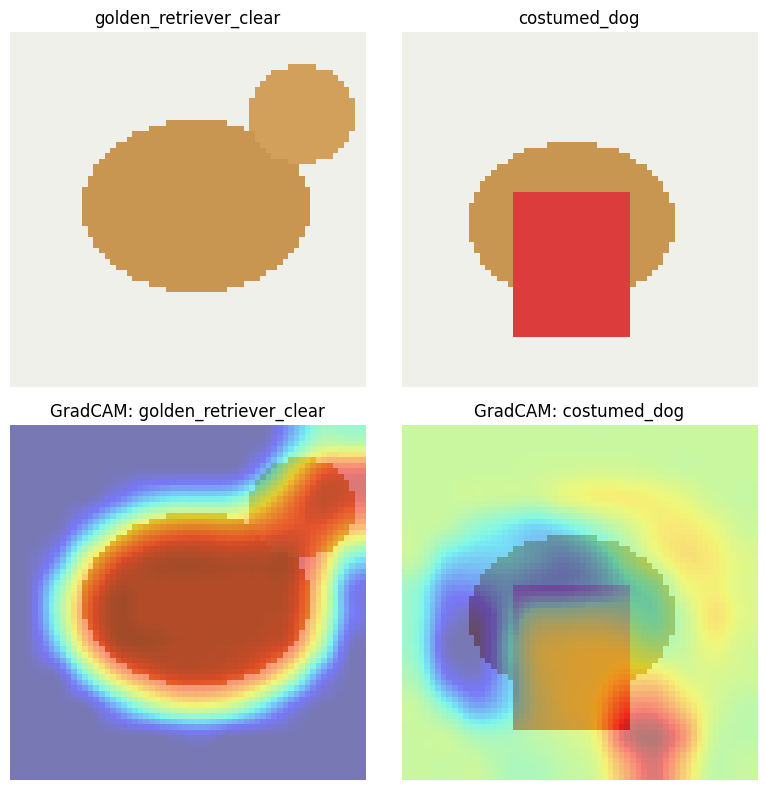

In [6]:
def gradcam(model, img, class_index=None, last_conv_layer_name=None):
    """A compact GradCAM implementation for a Keras Sequential/Functional model."""
    if model is None or not TF_AVAILABLE:
        return None

    if last_conv_layer_name is None:
        for layer in reversed(model.layers):
            if isinstance(layer, tf.keras.layers.Conv2D):
                last_conv_layer_name = layer.name
                break

    grad_model = tf.keras.models.Model(
        inputs=model.inputs, outputs=[model.get_layer(last_conv_layer_name).output, model.outputs[0]]
    )

    img_batch = img[np.newaxis, ...].astype(np.float32)
    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_batch)
        if class_index is None:
            class_index = tf.argmax(predictions[0])
        class_channel = predictions[:, class_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


if small_cnn is not None:
    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    for col, name in enumerate(["golden_retriever_clear", "costumed_dog"]):
        img = test_images[name]
        heatmap = gradcam(small_cnn, img)
        axes[0, col].imshow(img); axes[0, col].set_title(name); axes[0, col].axis("off")
        axes[1, col].imshow(img)
        if heatmap is not None:
            heatmap_resized = np.array(Image.fromarray((heatmap * 255).astype(np.uint8)).resize((IMG_SIZE, IMG_SIZE)))
            axes[1, col].imshow(heatmap_resized, cmap="jet", alpha=0.5)
        axes[1, col].set_title(f"GradCAM: {name}"); axes[1, col].axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Small CNN unavailable -- install TensorFlow to run GradCAM in this notebook.")


**Answer in this cell:**
- What regions does the model attend to for the golden retriever? Are they what you would expect?
- Does it attend to the same regions for the costumed dog? What changed?
- (If using real pretrained ResNet-50/EfficientNet-B0 in Colab) Does EfficientNet attend to different regions than ResNet? Are those regions more or less semantically meaningful?

## Part 3 — Confidence Under Noise

Gradually degrade the "golden retriever" image with Gaussian noise in five steps and record each model's top-1 confidence.

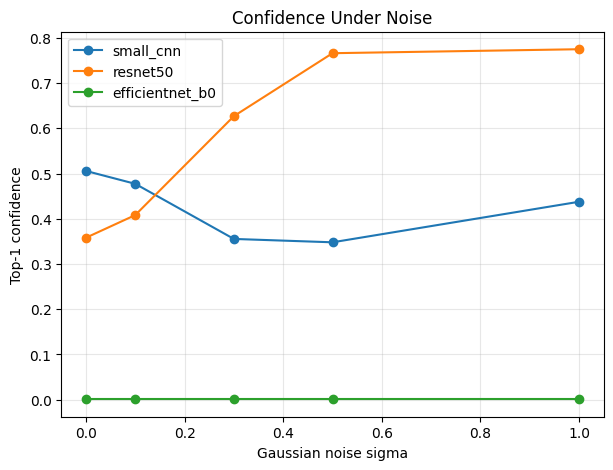

small_cnn: [0.51, 0.48, 0.36, 0.35, 0.44]
resnet50: [0.36, 0.41, 0.63, 0.77, 0.77]
efficientnet_b0: [0.0, 0.0, 0.0, 0.0, 0.0]


In [7]:
noise_levels = [0.0, 0.1, 0.3, 0.5, 1.0]
base_img = test_images["golden_retriever_clear"]

results = {"small_cnn": [], "resnet50": [], "efficientnet_b0": []}

for sigma in noise_levels:
    noisy = np.clip(base_img + np.random.RandomState(0).normal(0, sigma, base_img.shape), 0, 1)

    if small_cnn is not None:
        preds = predict_small_cnn(noisy)
        results["small_cnn"].append(preds[0][1])
    if TF_AVAILABLE and resnet50 is not None:
        preds = predict_imagenet_model(resnet50, noisy, resnet_preprocess, resnet_decode)
        results["resnet50"].append(preds[0][1])
    if TF_AVAILABLE and efficientnet_b0 is not None:
        preds = predict_imagenet_model(efficientnet_b0, noisy, eff_preprocess, eff_decode)
        results["efficientnet_b0"].append(preds[0][1])

plt.figure(figsize=(7, 5))
for model_name, confidences in results.items():
    if confidences:
        plt.plot(noise_levels, confidences, marker="o", label=model_name)
plt.xlabel("Gaussian noise sigma")
plt.ylabel("Top-1 confidence")
plt.title("Confidence Under Noise")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for model_name, confidences in results.items():
    if confidences:
        print(f"{model_name}: {[round(c, 2) for c in confidences]}")


**Answer in this cell:**
- Which model loses confidence fastest as noise increases?
- Which model is most resistant to noise? Is resistance always desirable?
- At what noise level do models begin predicting incorrect classes? Is the transition sudden or gradual?

## Reflection

Write three sentences:

1. What surprised you most about how the models differed?
2. What would you need to see to feel confident deploying one of these models in a medical imaging context?
3. What does the confidence calibration exercise reveal about the relationship between model confidence and model accuracy — and why does that relationship matter?

**Your reflection (edit this cell):**

1. _..._
2. _..._
3. _..._